In [ ]:
# Book Recommendation System

## Exploratory Data Analysis (EDA)

Dataset: Goodbooks-10k

Goal:
- Understand the dataset
- Find missing values
- Check data quality
- Analyze user behavior
- Analyze book popularity

In [1]:
## Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

plt.style.use("ggplot")

In [4]:
## Project Paths
from pathlib import Path

ROOT = Path("..")

DATASET = ROOT / "datasets" / "dataset_raw"
GOODREADS = ROOT / "datasets" / "goodreadsbooks_raw"
METADATA = ROOT / "datasets" / "metadata_dataset_raw"

In [5]:
## Verify Paths exist

print(DATASET.exists())
print(GOODREADS.exists())
print(METADATA.exists())

True
True
True


In [8]:
## Load datasets
books = pd.read_csv(DATASET / "books.csv")
ratings = pd.read_csv(DATASET / "ratings.csv")
tags = pd.read_csv(DATASET / "tags.csv")
book_tags = pd.read_csv(DATASET / "book_tags.csv")
to_read = pd.read_csv(DATASET / "to_read.csv")

# goodreads_books = pd.read_csv(GOODREADS / "books.csv")
# metadata = pd.read_csv(METADATA / "Goodreadss Books.csv")

In [11]:
## Verify files loaded
datasets = {
    "Books": books,
    "Ratings": ratings,
    "Tags": tags,
    "Book Tags": book_tags,
    "To Read": to_read,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Books: (10000, 23)
Ratings: (5976479, 3)
Tags: (34252, 2)
Book Tags: (999912, 3)
To Read: (912705, 2)


In [12]:
## Dataset shapes
datasets = {
    "Books": books,
    "Ratings": ratings,
    "Tags": tags,
    "Book Tags": book_tags,
    "To Read": to_read
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print(df.shape)

Books
(10000, 23)
Ratings
(5976479, 3)
Tags
(34252, 2)
Book Tags
(999912, 3)
To Read
(912705, 2)


In [13]:
## First five rows
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    display(df.head())

Books


,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m/2767052.jpg,https://images.gr-assets.com/books/1447303603s/2767052.jpg
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)",eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m/3.jpg,https://images.gr-assets.com/books/1474154022s/3.jpg
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m/41865.jpg,https://images.gr-assets.com/books/1361039443s/41865.jpg
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,4.25,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m/2657.jpg,https://images.gr-assets.com/books/1361975680s/2657.jpg
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,The Great Gatsby,eng,3.89,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m/4671.jpg,https://images.gr-assets.com/books/1490528560s/4671.jpg


Ratings


,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3


Tags


,tag_id,tag_name
0,0,-
1,1,--1-
2,2,--10-
3,3,--12-
4,4,--122-


Book Tags


,goodreads_book_id,tag_id,count
0,1,30574,167697
1,1,11305,37174
2,1,11557,34173
3,1,8717,12986
4,1,33114,12716


To Read


,user_id,book_id
0,9,8
1,15,398
2,15,275
3,37,7173
4,34,380


In [14]:
## Dataset information
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print(df.info())

Books
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   book_id                    10000 non-null  int64  
 1   goodreads_book_id          10000 non-null  int64  
 2   best_book_id               10000 non-null  int64  
 3   work_id                    10000 non-null  int64  
 4   books_count                10000 non-null  int64  
 5   isbn                       9300 non-null   str    
 6   isbn13                     9415 non-null   float64
 7   authors                    10000 non-null  str    
 8   original_publication_year  9979 non-null   float64
 9   original_title             9415 non-null   str    
 10  title                      10000 non-null  str    
 11  language_code              8916 non-null   str    
 12  average_rating             10000 non-null  float64
 13  ratings_count              10000 non-null  int64  
 

In [15]:
## Missing values
for name, df in datasets.items():
    print("=" * 60)
    print(name)

    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No missing values")
    else:
        display(missing.sort_values(ascending=False))

Books


language_code                1084
isbn                          700
isbn13                        585
original_title                585
original_publication_year      21
dtype: int64

Ratings
No missing values
Tags
No missing values
Book Tags
No missing values
To Read
No missing values


In [16]:
## Duplicate rows
for name, df in datasets.items():
    print(name, ":", df.duplicated().sum())

Books : 0
Ratings : 0
Tags : 0
Book Tags : 6
To Read : 0


In [17]:
## Duplicate Verification
duplicates = book_tags[book_tags.duplicated(keep=False)]
duplicates.sort_values(by=["goodreads_book_id", "tag_id"]).head(20)

,goodreads_book_id,tag_id,count
159370,22369,25148,4
159371,22369,25148,4
265139,52629,2928,1
265140,52629,2928,1
265127,52629,10094,1
265128,52629,10094,1
265154,52629,13272,1
265155,52629,13272,1
265186,52629,13322,1
265187,52629,13322,1


In [18]:
## Statistical summary
display(books.describe(include="all"))
display(ratings.describe())

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
count,10000.00000,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,9300,9.415000e+03,10000,9979.000000,9415,10000,8916,10000.000000,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000,10000
unique,NaN,NaN,NaN,NaN,NaN,9300,NaN,4664,NaN,9274,9964,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6669,6669
top,NaN,NaN,NaN,NaN,NaN,439023483,NaN,Stephen King,NaN,,Selected Poems,eng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://s.gr-assets.com/assets/nophoto/book/111x148-bcc042a9c91a29c1d680899eff700a03.png,https://s.gr-assets.com/assets/nophoto/book/50x75-a91bf249278a81aabab721ef782c4a74.png
freq,NaN,NaN,NaN,NaN,NaN,1,NaN,60,NaN,5,4,6341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3332,3332
mean,5000.50000,5.264697e+06,5.471214e+06,8.646183e+06,75.712700,NaN,9.755044e+12,NaN,1981.987674,NaN,NaN,NaN,4.002191,5.400124e+04,5.968732e+04,2919.955300,1345.040600,3110.885000,11475.893800,1.996570e+04,2.378981e+04,NaN,NaN
std,2886.89568,7.575462e+06,7.827330e+06,1.175106e+07,170.470728,NaN,4.428619e+11,NaN,152.576665,NaN,NaN,NaN,0.254427,1.573700e+05,1.678038e+05,6124.378132,6635.626263,9717.123578,28546.449183,5.144736e+04,7.976889e+04,NaN,NaN
min,1.00000,1.000000e+00,1.000000e+00,8.700000e+01,1.000000,NaN,1.951703e+08,NaN,-1750.000000,NaN,NaN,NaN,2.470000,2.716000e+03,5.510000e+03,3.000000,11.000000,30.000000,323.000000,7.500000e+02,7.540000e+02,NaN,NaN
25%,2500.75000,4.627575e+04,4.791175e+04,1.008841e+06,23.000000,NaN,9.780316e+12,NaN,1990.000000,NaN,NaN,NaN,3.850000,1.356875e+04,1.543875e+04,694.000000,196.000000,656.000000,3112.000000,5.405750e+03,5.334000e+03,NaN,NaN
50%,5000.50000,3.949655e+05,4.251235e+05,2.719524e+06,40.000000,NaN,9.780452e+12,NaN,2004.000000,NaN,NaN,NaN,4.020000,2.115550e+04,2.383250e+04,1402.000000,391.000000,1163.000000,4894.000000,8.269500e+03,8.836000e+03,NaN,NaN
75%,7500.25000,9.382225e+06,9.636112e+06,1.451775e+07,67.000000,NaN,9.780831e+12,NaN,2011.000000,NaN,NaN,NaN,4.180000,4.105350e+04,4.591500e+04,2744.250000,885.000000,2353.250000,9287.000000,1.602350e+04,1.730450e+04,NaN,NaN


,user_id,book_id,rating
count,5.976479e+06,5.976479e+06,5.976479e+06
mean,2.622446e+04,2.006477e+03,3.919866e+00
std,1.541323e+04,2.468499e+03,9.910868e-01
min,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.281300e+04,1.980000e+02,3.000000e+00
50%,2.593800e+04,8.850000e+02,4.000000e+00
75%,3.950900e+04,2.973000e+03,5.000000e+00
max,5.342400e+04,1.000000e+04,5.000000e+00


rating
1     124195
2     359257
3    1370916
4    2139018
5    1983093
Name: count, dtype: int64

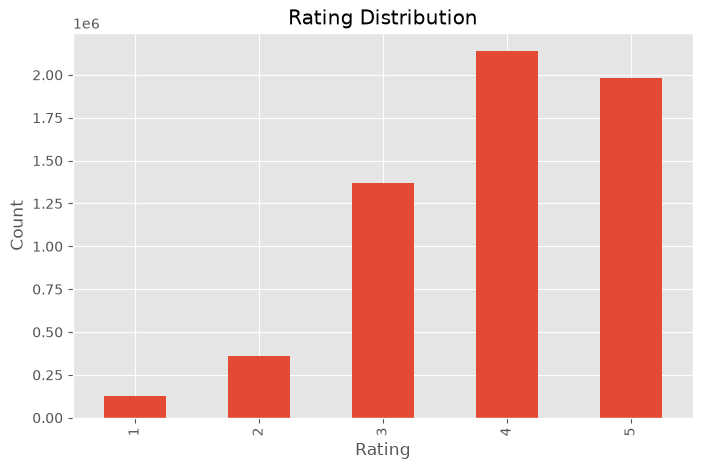

In [19]:
## Rating distribution
rating_counts = ratings["rating"].value_counts().sort_index()

display(rating_counts)

rating_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [20]:
## Ratings per user
ratings_per_user = ratings.groupby("user_id").size()

display(ratings_per_user.describe())


count    53424.000000
mean       111.868804
std         26.071224
min         19.000000
25%         96.000000
50%        111.000000
75%        128.000000
max        200.000000
dtype: float64

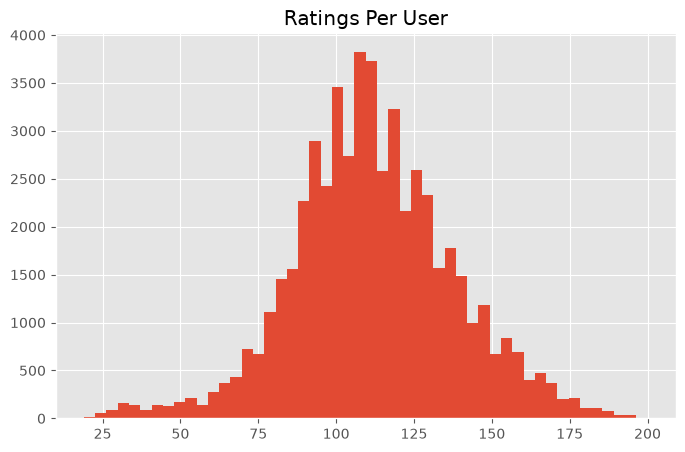

In [23]:
## Histogram
ratings_per_user.hist(
    bins=50,
    figsize=(8,5)
)

plt.title("Ratings Per User")

plt.show()

In [24]:
## Ratings per book
ratings_per_book = ratings.groupby("book_id").size()

display(ratings_per_book.describe())

count    10000.000000
mean       597.647900
std       1267.289788
min          8.000000
25%        155.000000
50%        248.000000
75%        503.000000
max      22806.000000
dtype: float64

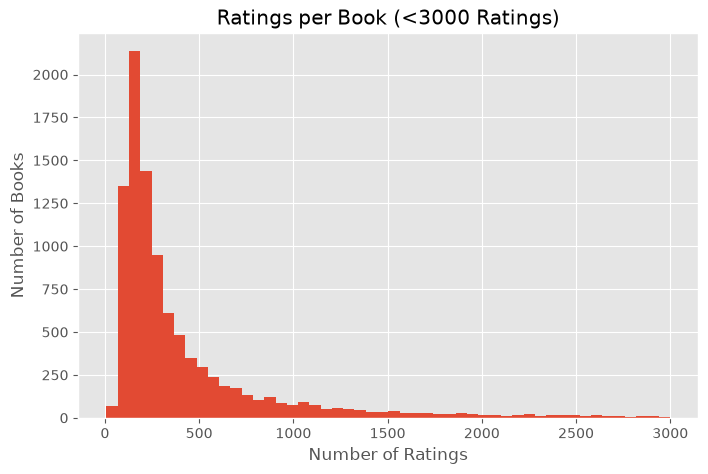

In [30]:
## Histogram
ratings_per_book.hist(
    bins=50,
    figsize=(8,5)
)

plt.title("Ratings Per Book")

plt.show()


In [31]:
## Top 20 popular books
popular = (
    ratings.groupby("book_id")
    .size()
    .reset_index(name="rating_count")
)

popular = popular.merge(
    books[
        [
            "book_id",
            "title",
            "authors"
        ]
    ],
    on="book_id"
)

popular = popular.sort_values(
    "rating_count",
    ascending=False
)

display(popular.head(20))

,book_id,rating_count,title,authors
0,1,22806,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins
1,2,21850,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)","J.K. Rowling, Mary GrandPré"
3,4,19088,To Kill a Mockingbird,Harper Lee
2,3,16931,"Twilight (Twilight, #1)",Stephenie Meyer
4,5,16604,The Great Gatsby,F. Scott Fitzgerald
16,17,16549,"Catching Fire (The Hunger Games, #2)",Suzanne Collins
19,20,15953,"Mockingjay (The Hunger Games, #3)",Suzanne Collins
17,18,15855,"Harry Potter and the Prisoner of Azkaban (Harry Potter, #3)","J.K. Rowling, Mary GrandPré, Rufus Beck"
22,23,15657,"Harry Potter and the Chamber of Secrets (Harry Potter, #2)","J.K. Rowling, Mary GrandPré"
6,7,15558,The Hobbit,J.R.R. Tolkien


In [32]:
## Highest rated books
highest = (
    books[
        [
            "title",
            "authors",
            "average_rating",
            "ratings_count"
        ]
    ]
)

highest = highest[
    highest["ratings_count"] > 1000
]

highest = highest.sort_values(
    "average_rating",
    ascending=False
)

display(highest.head(20))

,title,authors,average_rating,ratings_count
3627,The Complete Calvin and Hobbes,Bill Watterson,4.82,28900
861,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,4.77,73572
3274,"Harry Potter Boxed Set, Books 1-5 (Harry Potter, #1-5)","J.K. Rowling, Mary GrandPré",4.77,33220
7946,ESV Study Bible,"Anonymous, Lane T. Dennis, Wayne A. Grudem",4.76,8953
8853,Mark of the Lion Trilogy,Francine Rivers,4.76,9081
4482,It's a Magical World: A Calvin and Hobbes Collection,Bill Watterson,4.75,22351
6360,There's Treasure Everywhere: A Calvin and Hobbes Collection,Bill Watterson,4.74,16766
421,"Harry Potter Boxset (Harry Potter, #1-7)",J.K. Rowling,4.74,190050
3752,"Harry Potter Collection (Harry Potter, #1-6)",J.K. Rowling,4.73,24618
6919,The Indispensable Calvin and Hobbes,Bill Watterson,4.73,14597


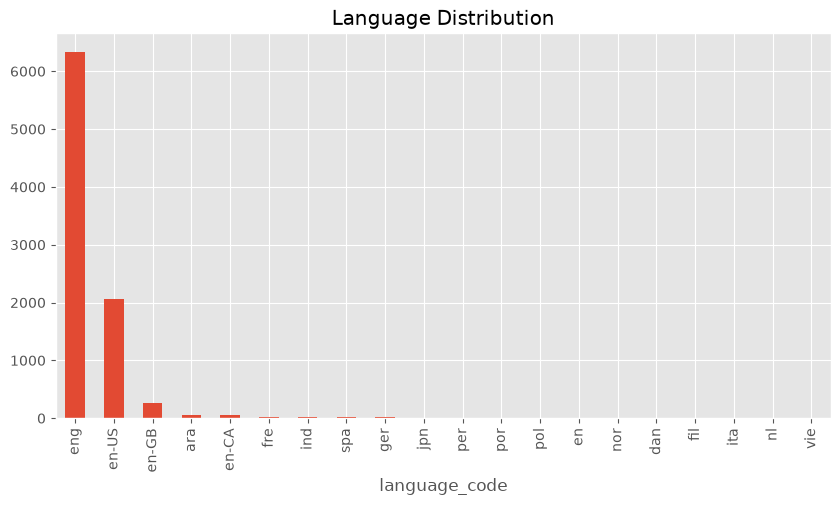

In [33]:
## Language distribution
books["language_code"].value_counts().head(20).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Language Distribution")

plt.show()

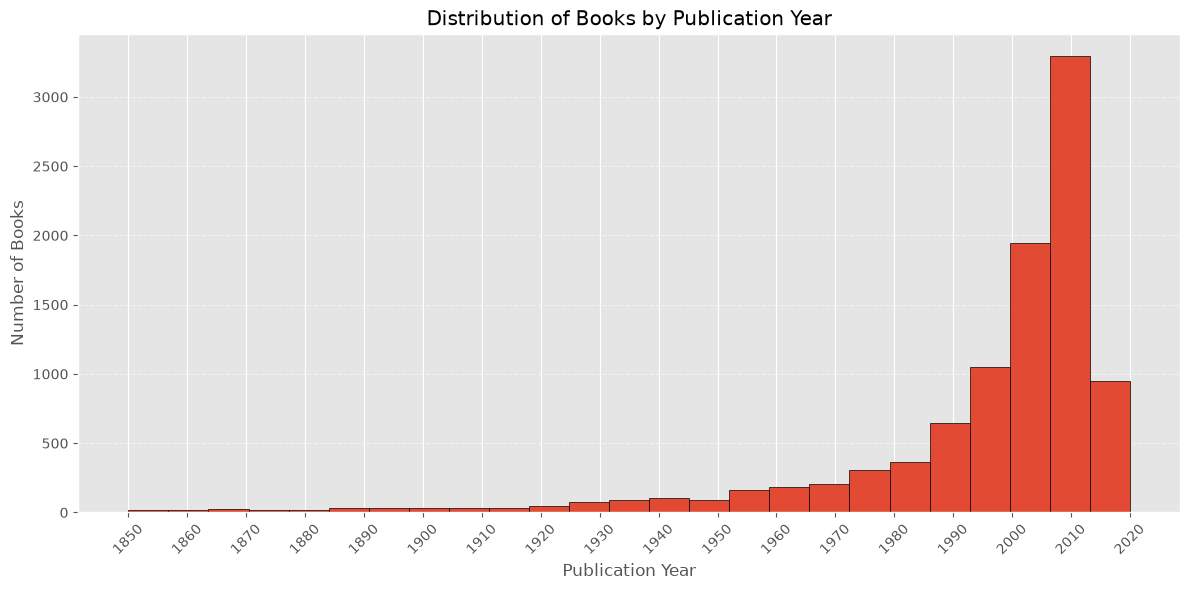

In [39]:
## Publication year
import matplotlib.pyplot as plt

publication_years = books["original_publication_year"].dropna()
publication_years = publication_years[publication_years > 0]

plt.figure(figsize=(12, 6))

plt.hist(
    publication_years,
    bins=25,
    range=(1850, 2020),   # <-- offset starts at 1850
    edgecolor="black"
)

plt.title("Distribution of Books by Publication Year")
plt.xlabel("Publication Year")
plt.ylabel("Number of Books")

plt.xticks(range(1850, 2021, 10), rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [40]:
## Most common tags
merged_tags = book_tags.merge(
    tags,
    on="tag_id"
)

top_tags = (
    merged_tags.groupby("tag_name")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

display(top_tags)

tag_name
to-read              9983
favorites            9881
owned                9858
books-i-own          9799
currently-reading    9776
library              9415
owned-books          9221
fiction              9097
to-buy               8692
kindle               8316
default              8239
ebook                8054
my-books             7561
audiobook            7242
ebooks               7203
wish-list            7192
my-library           7000
audiobooks           6862
i-own                6670
adult                6604
dtype: int64

In [49]:
## Books with most tags
top_tags = (
    book_tags.merge(tags, on="tag_id")
    .groupby("tag_name")
    .size()
    .sort_values(ascending=False)
)

display(top_tags.head(20))

tag_name
to-read              9983
favorites            9881
owned                9858
books-i-own          9799
currently-reading    9776
library              9415
owned-books          9221
fiction              9097
to-buy               8692
kindle               8316
default              8239
ebook                8054
my-books             7561
audiobook            7242
ebooks               7203
wish-list            7192
my-library           7000
audiobooks           6862
i-own                6670
adult                6604
dtype: int64

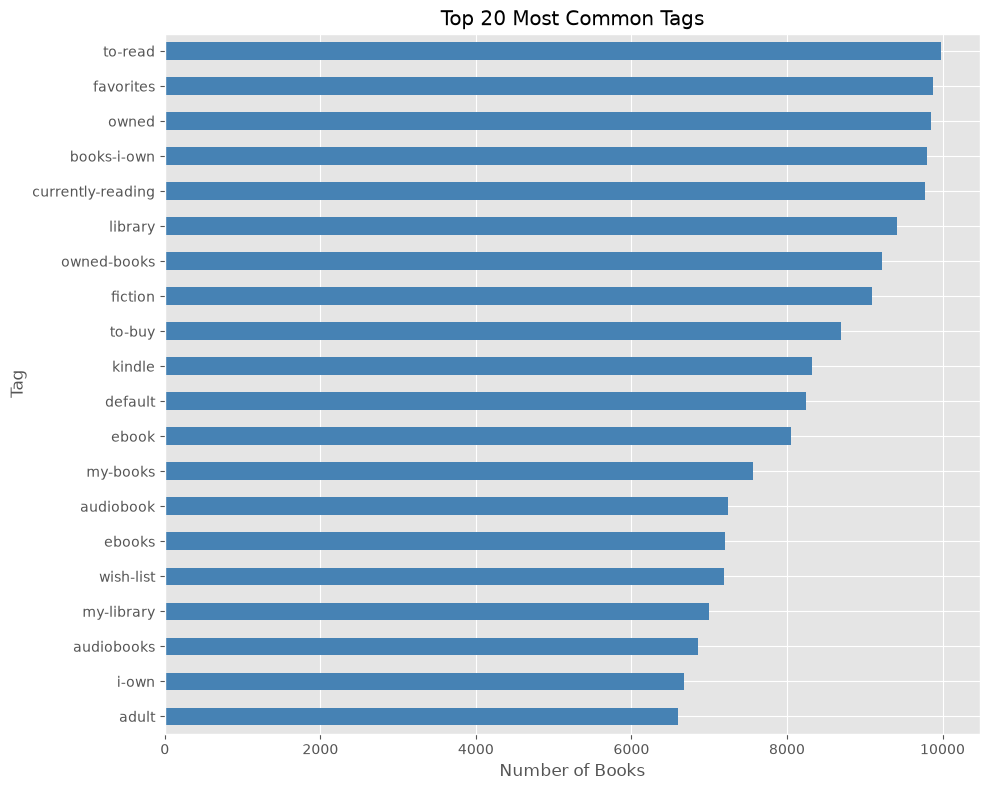

In [51]:
## Books with most tags visualised
top_tags = (
    book_tags.merge(tags, on="tag_id")
    .groupby("tag_name")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))

top_tags.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 20 Most Common Tags")
plt.xlabel("Number of Books")
plt.ylabel("Tag")

plt.tight_layout()
plt.show()

In [42]:
## To Read statistics
display(to_read.describe())

,user_id,book_id
count,912705.000000,912705.000000
mean,27668.980115,2454.739538
std,14775.096388,2626.359921
min,1.000000,1.000000
25%,15507.000000,360.000000
50%,27799.000000,1381.000000
75%,40220.000000,3843.000000
max,53424.000000,10000.000000


In [48]:
## Correlation matrix
numeric = books.select_dtypes(include=np.number)

corr = numeric.corr(numeric_only=True)

display(corr)

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn13,original_publication_year,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
book_id,1.000000,0.115154,0.104516,0.113861,-0.263841,-0.011291,0.049875,-0.040880,-0.373178,-0.382656,-0.419292,-0.239401,-0.345764,-0.413279,-0.407079,-0.332486
goodreads_book_id,0.115154,1.000000,0.966620,0.929356,-0.164578,-0.048246,0.133790,-0.024848,-0.073023,-0.063760,0.118845,-0.038375,-0.056571,-0.075634,-0.063310,-0.056145
best_book_id,0.104516,0.966620,1.000000,0.899258,-0.159240,-0.047253,0.131442,-0.021187,-0.069182,-0.055835,0.125893,-0.033894,-0.049284,-0.067014,-0.054462,-0.049524
work_id,0.113861,0.929356,0.899258,1.000000,-0.109436,-0.039320,0.107972,-0.017555,-0.062720,-0.054712,0.096985,-0.034590,-0.051367,-0.066746,-0.054775,-0.046745
books_count,-0.263841,-0.164578,-0.159240,-0.109436,1.000000,0.017865,-0.321753,-0.069888,0.324235,0.333664,0.198698,0.225763,0.334923,0.383699,0.349564,0.279559
isbn13,-0.011291,-0.048246,-0.047253,-0.039320,0.017865,1.000000,-0.004612,-0.025667,0.008904,0.009166,0.009553,0.006054,0.010345,0.012142,0.010161,0.006622
original_publication_year,0.049875,0.133790,0.131442,0.107972,-0.321753,-0.004612,1.000000,0.015608,-0.024415,-0.025448,0.027784,-0.019635,-0.038472,-0.042459,-0.025785,-0.015388
average_rating,-0.040880,-0.024848,-0.021187,-0.017555,-0.069888,-0.025667,0.015608,1.000000,0.044990,0.045042,0.007481,-0.077997,-0.115875,-0.065237,0.036108,0.115412
ratings_count,-0.373178,-0.073023,-0.069182,-0.062720,0.324235,0.008904,-0.024415,0.044990,1.000000,0.995068,0.779635,0.723144,0.845949,0.935193,0.978869,0.964046
work_ratings_count,-0.382656,-0.063760,-0.055835,-0.054712,0.333664,0.009166,-0.025448,0.045042,0.995068,1.000000,0.807009,0.718718,0.848581,0.941182,0.987764,0.966587


In [47]:
## Final summary
print(f"Books                 : {len(books):,}")
print(f"Ratings               : {len(ratings):,}")
print(f"Users                 : {ratings['user_id'].nunique():,}")
print(f"Books Rated           : {ratings['book_id'].nunique():,}")
print(f"Average Rating        : {ratings['rating'].mean():.2f}")
print(f"Average Ratings/User  : {ratings.groupby('user_id').size().mean():.2f}")
print(f"Average Ratings/Book  : {ratings.groupby('book_id').size().mean():.2f}")

Books                 : 10,000
Ratings               : 5,976,479
Users                 : 53,424
Books Rated           : 10,000
Average Rating        : 3.92
Average Ratings/User  : 111.87
Average Ratings/Book  : 597.65


In [ ]:
## Ratings per User Analysis

- Total users: **53,424**
- Average ratings per user: **111.87**
- Median ratings per user: **111**
- Minimum ratings by a user: **19**
- Maximum ratings by a user: **200**

### Observations

- The dataset contains active users with a substantial number of ratings.
- The average and median are nearly identical, indicating a relatively balanced distribution of user activity.
- Since every user has rated at least 19 books, filtering inactive users is unlikely to be necessary.
- This is beneficial for collaborative filtering models such as LightGCN because each user has enough interaction history.

In [ ]:
## Summary of Findings

### Books Dataset
- Contains 10,000 books.
- Several metadata fields have missing values (`isbn`, `isbn13`, `language_code`, `original_title`, `original_publication_year`).
- Average book rating is approximately **4.0**.
- Most books are written in English.
- Ratings count is highly skewed, with a few books receiving millions of ratings.
- Publication years range from **-1750** to **2017** and require further inspection.

### Ratings Dataset
- Contains **5,976,479** user-book interactions.
- Ratings range from **1 to 5**.
- Average user rating is **3.92**, indicating generally positive feedback.
- The dataset is suitable for collaborative filtering techniques such as LightGCN.

In [ ]:
## Ratings per Book Analysis

- Total books: **10,000**
- Average ratings per book: **597.65**
- Median ratings per book: **248**
- Minimum ratings for a book: **8**
- Maximum ratings for a book: **22,806**

### Observations

- Book popularity is highly uneven.
- Most books receive relatively few ratings, while a small number of books receive a very large number of ratings.
- The difference between the mean (597.65) and median (248) indicates a right-skewed distribution.
- This imbalance should be considered when designing recommendation models to avoid over-recommending only the most popular books.

In [ ]:
## Correlation Analysis

### Key Findings

- `ratings_count` and `work_ratings_count` are almost perfectly correlated (0.995), indicating they contain nearly identical information.
- Rating count columns (`ratings_1`–`ratings_5`) are strongly correlated with total ratings because they contribute directly to the overall rating count.
- `average_rating` exhibits only weak correlations with other numerical variables, suggesting that popularity does not necessarily imply a higher average rating.
- Identifier columns (`book_id`, `goodreads_book_id`, `best_book_id`, and `work_id`) are unique identifiers and are not suitable as predictive features.

In [ ]:
## To Read Dataset

- Contains **912,705** user-book pairs.
- Covers the complete user base and book catalog.
- Can be used to model user interest beyond explicit ratings.

In [ ]:
## Book Tags Analysis

Several books contain exactly **100 tag assignments**, suggesting the dataset limits the number of stored tags per book. Consequently, tag counts should not be interpreted as the true popularity of a book's tags.

In [ ]:
### Duplicate Rows Analysis

The `book_tags` dataset contains **6 exact duplicate rows**.

These duplicates have identical values for:
- `goodreads_book_id`
- `tag_id`
- `count`

Since they are exact duplicates and provide no additional information, they will be removed during preprocessing using `drop_duplicates()`.

In [ ]:
## Most Common Tags

The most frequently assigned tags are dominated by **reading status** and **personal library organization** rather than book genres.

### Top Tags

| Tag | Books |
|------|------:|
| to-read | 9,983 |
| favorites | 9,881 |
| owned | 9,858 |
| books-i-own | 9,799 |
| currently-reading | 9,776 |
| library | 9,415 |
| owned-books | 9,221 |
| fiction | 9,097 |
| to-buy | 8,692 |
| kindle | 8,316 |

### Observations

- The most common tag is **"to-read"**, appearing on **9,983** books.
- Many frequently occurring tags represent **user reading status** (e.g., *to-read*, *currently-reading*) rather than book content.
- Several tags describe **personal collections** (e.g., *owned*, *library*, *books-i-own*).
- Genre-related tags such as **fiction** appear less frequently than organizational tags.
- These tags may be useful as additional metadata for content-based recommendation models, although user-specific organizational tags should be interpreted carefully.

In [ ]:
## Dataset Summary

| Metric | Value |
|--------|-------:|
| Total Books | 10,000 |
| Total Ratings | 5,976,479 |
| Total Users | 53,424 |
| Books with Ratings | 10,000 |
| Average Rating | 3.92 |
| Average Ratings per User | 111.87 |
| Average Ratings per Book | 597.65 |

### Observations

- The dataset contains **10,000 books** and **53,424 users**.
- Every book has received at least one rating, indicating complete coverage of the catalog.
- The dataset contains nearly **6 million user-book interactions**, making it well suited for collaborative filtering methods.
- The average user has rated approximately **112 books**, suggesting users have sufficient interaction history for personalized recommendations.
- Each book receives an average of **598 ratings**, although popularity varies considerably across books.
- The average rating is **3.92/5**, indicating that users generally rate books positively.

In [ ]:
# EDA Summary

## Key Findings

- The dataset contains **10,000 books**, **53,424 users**, and nearly **6 million ratings**.
- Duplicate rows were found only in `book_tags.csv` and will be removed during preprocessing.
- Missing values exist primarily in ISBN, language code, original title, and publication year.
- User activity is well distributed, with an average of approximately **112 ratings per user**.
- Book popularity is highly imbalanced, with a small number of books receiving significantly more ratings than others.
- Publication years are concentrated in recent decades.
- Average ratings are generally high (approximately **3.92/5**).
- Goodreads tags are dominated by organizational tags (e.g., *to-read*, *owned*) rather than genres.
- Several metadata columns are highly correlated and may be redundant for modeling.

## Next Steps

The next stage is data preprocessing, which will include:
- Handling missing values.
- Removing duplicate records.
- Cleaning publication years.
- Selecting useful features.
- Preparing interaction data for recommendation models.